X shape: (300, 2)  | goal shape: (300, 1)
primi 5 goal: [1 1 1 0 7]


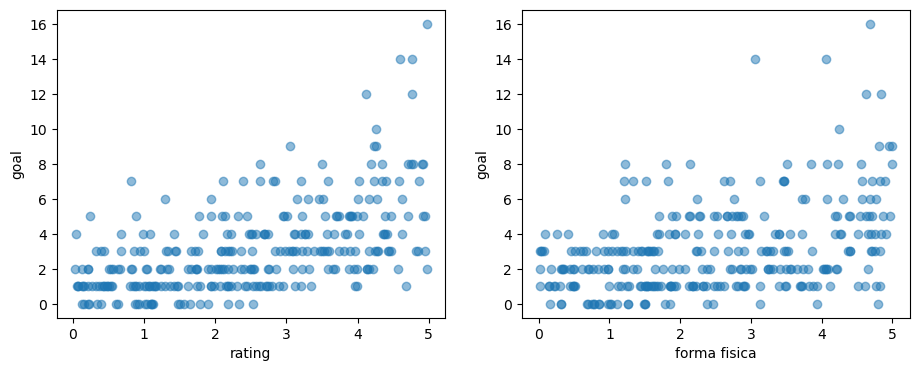

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)

# 300 giocatori, DUE feature (entrambe tra 0 e 5)
rating  = np.random.uniform(0, 5, (300, 1))   # x1 = abilità
fitness = np.random.uniform(0, 5, (300, 1))   # x2 = forma fisica
X = np.hstack([rating, fitness])              # matrice delle feature -> (300, 2)

# goal = conteggio.
goal = np.random.poisson(np.exp(-0.5 + 0.35*rating + 0.25*fitness)).reshape(-1, 1)

print("X shape:", X.shape, " | goal shape:", goal.shape)
print("primi 5 goal:", goal[:5].ravel())

# Guardiamo come i goal dipendono da CIASCUNA feature
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.scatter(rating,  goal, alpha=0.5); a1.set_xlabel("rating");       a1.set_ylabel("goal")
a2.scatter(fitness, goal, alpha=0.5); a2.set_xlabel("forma fisica"); a2.set_ylabel("goal")
plt.show()

In [5]:
# Aggiungo la colonna x0 = 1 (trucco dell'intercetta) -> X_b shape (300, 3)
m = X.shape[0]
X_b = np.hstack([np.ones((m, 1)), X])
print("X_b shape:", X_b.shape)

# theta: 3 numeri -> theta0 (base), theta1 (peso del rating), theta2 (peso della forma)
theta = np.zeros((3, 1))

# Il modello Poisson: h(x) = e^(theta^T x)
def ipotesi(X_b, theta):
  return np.exp(X_b @ theta)

# Con theta = 0:  e^0 = 1  -> il modello NON allenato predice 1 goal per tutti
print("prime 5 predizioni (theta=0):", ipotesi(X_b, theta)[:5].ravel())

X_b shape: (300, 3)
prime 5 predizioni (theta=0): [1. 1. 1. 1. 1.]


In [6]:
alpha = 0.003              # learning rate piccolo: SGD fa un passo per ogni giocatore
theta = np.zeros((3, 1))   # riparto da zero per vedere bene UN update

# Prendo UN giocatore: il n. 4 (segna 7 goal -> vediamo che il modello sbaglia di brutto)
j = 4
x_i = X_b[j:j+1]           # le sue feature [1, rating, fitness] -> (1, 3)
y_i = goal[j:j+1]          # i suoi goal veri -> (1, 1)
print("giocatore", j, "-> x_i =", x_i.ravel().round(2), "| goal veri =", int(y_i.item()))

# 1. Cosa predice ORA il modello (con theta = 0)?
h_i = ipotesi(x_i, theta)
print("1) predizione attuale:", h_i.ravel().round(3))

# 2. Errore = h - y   (negativo = ho predetto TROPPO POCO)
print("2) errore (h - y):", (h_i - y_i).ravel().round(3))

# 3. Gradiente per questo esempio = (h - y) * x   <- il (h-y)x di Ng
gradiente = x_i.T @ (h_i - y_i)
print("3) gradiente (h-y)x:", gradiente.ravel().round(3))

# 4. Aggiorno: theta = theta - alpha * gradiente
theta = theta - alpha * gradiente
print("4) theta dopo 1 update:", theta.ravel().round(4))

# Ricontrollo la predizione per LO STESSO giocatore
print("   predizione DOPO:", ipotesi(x_i, theta).ravel().round(3))

giocatore 4 -> x_i = [1.   2.1  4.71] | goal veri = 7
1) predizione attuale: [1.]
2) errore (h - y): [-6.]
3) gradiente (h-y)x: [ -6.    -12.611 -28.273]
4) theta dopo 1 update: [0.018  0.0378 0.0848]
   predizione DOPO: [1.644]


In [7]:
theta = np.zeros((3, 1))   # riparto da zero
alpha = 0.003
epoche = 120

for epoca in range(epoche):
  for i in np.random.permutation(m):       # tutti i giocatori, in ordine casuale
      x_i = X_b[i:i+1]
      y_i = goal[i:i+1]
      h_i = ipotesi(x_i, theta)            # predizione per QUESTO giocatore
      gradiente = x_i.T @ (h_i - y_i)      # (h - y) x   <- forma discesa
      theta = theta - alpha * gradiente    # scendo

  if epoca % 20 == 0 or epoca == epoche - 1:
      print(f"epoca {epoca:3d} -> theta = {theta.ravel().round(3)}")

print("theta vero          : [-0.5, 0.35, 0.25]")

epoca   0 -> theta = [-0.054  0.265  0.215]
epoca  20 -> theta = [-0.465  0.294  0.155]
epoca  40 -> theta = [-0.463  0.369  0.335]
epoca  60 -> theta = [-0.481  0.332  0.272]
epoca  80 -> theta = [-0.455  0.341  0.213]
epoca 100 -> theta = [-0.464  0.352  0.19 ]
epoca 119 -> theta = [-0.436  0.306  0.281]
theta vero          : [-0.5, 0.35, 0.25]


In [8]:
def newton_version():
    theta = np.zeros((3, 1))
    
    for iterazione in range(8):
      h = ipotesi(X_b, theta)              # = lambda previsto per ogni giocatore (m,1)
    
      # Gradiente: (h - y) x, sommato su TUTTI i giocatori (batch) -> (3,1)
      gradiente = X_b.T @ (h - goal)
    
      # Hessiana: Xᵀ diag(peso) X, con peso = varianza Poisson = lambda = h
      S = h                                # (m,1)
      H = X_b.T @ (S * X_b)                # (3,3)
    
      # Passo di Newton: theta := theta - H^{-1} gradiente
      theta = theta - np.linalg.solve(H, gradiente)
    
      print(f"iter {iterazione} -> theta = {theta.ravel().round(4)}")
    
    print("theta vero -> [-0.5, 0.35, 0.25]")

Giocatore (rating 4, fitness 3) -> goal attesi: 5.1
media goal reali   : 3.09
media goal previsti: 3.25
primi 5 -> reali: [1 1 1 0 7]  previsti: [1.31 1.14 1.71 1.66 4.62]


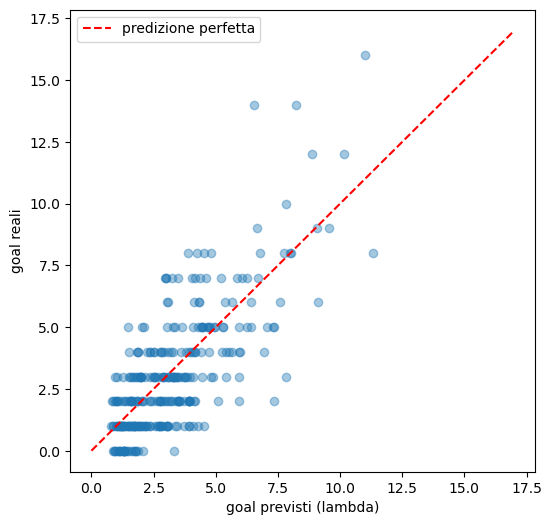

In [9]:
# 1. Predizione per un GIOCATORE NUOVO: rating 4, forma fisica 3
nuovo = np.array([1.0, 4.0, 3.0])           # [x0=1, rating, fitness]
print("Giocatore (rating 4, fitness 3) -> goal attesi:",
    round(float(np.exp(nuovo @ theta.ravel())), 2))

# 2. Quanto azzecca sui dati? lambda (goal attesi) per ogni giocatore
lam = ipotesi(X_b, theta)
print("media goal reali   :", round(float(goal.mean()), 2))
print("media goal previsti:", round(float(lam.mean()), 2))
print("primi 5 -> reali:", goal[:5].ravel(), " previsti:", lam[:5].ravel().round(2))

# 3. Grafico: goal previsti (lambda) vs reali
plt.figure(figsize=(6, 6))
plt.scatter(lam, goal, alpha=0.4)
lim = [0, float(goal.max()) + 1]
plt.plot(lim, lim, 'r--', label='predizione perfetta')
plt.xlabel("goal previsti (lambda)"); plt.ylabel("goal reali")
plt.legend(); plt.show()